In [1]:
import os
import json
import math
import textwrap
from datetime import datetime, timedelta
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 200)

sns.set_theme(style="whitegrid")

OUTPUT_DIR = "uc4_adaptive_care_focus_outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("UC4 prototype output directory:", OUTPUT_DIR)

UC4 prototype output directory: uc4_adaptive_care_focus_outputs


In [3]:
UC4_DOMAINS = [
    "PAIN_BEHAVIOR",
    "TONE_SPASTICITY",
    "POSITIONING_MOVEMENT_QUALITY",
    "SEIZURE_LIKE_EVENT_HISTORY",
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK",
    "BREATHING_OXYGEN",
    "SLEEP_RECOVERY",
    "BOWEL_BLADDER",
    "MOBILITY_TRANSFERS",
    "SKIN_PRESSURE_RISK",
    "CARDIOVASCULAR_BP_HR_FOLLOWUP",
    "METABOLIC_LABS_GLUCOSE_LIPIDS",
    "NUTRITION_HYDRATION",
    "PROVIDER_LAB_FOLLOWUP",
    "DATA_QUALITY_OR_MISSING_INFORMATION"
]

DOMAIN_LABELS = {
    "PAIN_BEHAVIOR": "Pain Behavior",
    "TONE_SPASTICITY": "Tone / Stiffness",
    "POSITIONING_MOVEMENT_QUALITY": "Positioning & Movement Quality",
    "SEIZURE_LIKE_EVENT_HISTORY": "Seizure-like Event History",
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK": "Medication-Aware Watch Area",
    "BREATHING_OXYGEN": "Breathing / Oxygen",
    "SLEEP_RECOVERY": "Sleep / Recovery",
    "BOWEL_BLADDER": "Bowel / Bladder",
    "MOBILITY_TRANSFERS": "Mobility / Transfers",
    "SKIN_PRESSURE_RISK": "Skin / Pressure Risk",
    "CARDIOVASCULAR_BP_HR_FOLLOWUP": "Cardiovascular / BP-HR Follow-up",
    "METABOLIC_LABS_GLUCOSE_LIPIDS": "Metabolic / Labs / Glucose / Lipids",
    "NUTRITION_HYDRATION": "Nutrition / Hydration",
    "PROVIDER_LAB_FOLLOWUP": "Provider / Lab Follow-up",
    "DATA_QUALITY_OR_MISSING_INFORMATION": "Data Quality / Missing Information"
}

DOMAIN_DESCRIPTIONS = {
    "PAIN_BEHAVIOR": "Tracks caregiver-observed pain behaviors such as guarding, grimacing, withdrawal, irritability, or sleep disruption.",
    "TONE_SPASTICITY": "Tracks caregiver-observed stiffness, spasms, tone-related changes, and movement comfort. Does not measure tone clinically.",
    "POSITIONING_MOVEMENT_QUALITY": "Tracks sitting posture, leaning/slumping, repositioning difficulty, movement quality, and positioning-related discomfort.",
    "SEIZURE_LIKE_EVENT_HISTORY": "Supports structured logging of seizure-like events and recovery context. Does not detect seizures.",
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK": "Tracks medication timing, missed doses, recent changes, and medication-aware watch areas without recommending treatment changes.",
    "BREATHING_OXYGEN": "Tracks SpO2, respiratory concerns, oxygen use context, and caregiver-observed breathing difficulty.",
    "SLEEP_RECOVERY": "Tracks sleep quality, recovery, fatigue, nighttime disruptions, and downstream effects on function.",
    "BOWEL_BLADDER": "Tracks bowel/bladder routines, constipation, catheterization concerns, hydration, and related discomfort.",
    "MOBILITY_TRANSFERS": "Tracks transfer difficulty, assistance needs, falls, and mobility changes.",
    "SKIN_PRESSURE_RISK": "Tracks pressure areas, redness, skin checks, immobility, and positioning-related skin risk.",
    "CARDIOVASCULAR_BP_HR_FOLLOWUP": "Tracks BP/HR-related follow-up areas when relevant from profile, meds, or events.",
    "METABOLIC_LABS_GLUCOSE_LIPIDS": "Tracks lab and metabolic follow-up such as glucose or lipid-related care areas.",
    "NUTRITION_HYDRATION": "Tracks fluid intake, meals, weight trends, and hydration-related caregiver observations.",
    "PROVIDER_LAB_FOLLOWUP": "Tracks overdue provider appointments, labs, care-plan reviews, and follow-up tasks.",
    "DATA_QUALITY_OR_MISSING_INFORMATION": "Flags missing/stale data that affects care-priority confidence."
}

pd.DataFrame({
    "domain": UC4_DOMAINS,
    "label": [DOMAIN_LABELS[d] for d in UC4_DOMAINS],
    "description": [DOMAIN_DESCRIPTIONS[d] for d in UC4_DOMAINS]
})

,domain,label,description
0,PAIN_BEHAVIOR,Pain Behavior,"Tracks caregiver-observed pain behaviors such as guarding, grimacing, withdrawal, irritability, or sleep disruption."
1,TONE_SPASTICITY,Tone / Stiffness,"Tracks caregiver-observed stiffness, spasms, tone-related changes, and movement comfort. Does not measure tone clinically."
2,POSITIONING_MOVEMENT_QUALITY,Positioning & Movement Quality,"Tracks sitting posture, leaning/slumping, repositioning difficulty, movement quality, and positioning-related discomfort."
3,SEIZURE_LIKE_EVENT_HISTORY,Seizure-like Event History,Supports structured logging of seizure-like events and recovery context. Does not detect seizures.
4,MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK,Medication-Aware Watch Area,"Tracks medication timing, missed doses, recent changes, and medication-aware watch areas without recommending treatment changes."
5,BREATHING_OXYGEN,Breathing / Oxygen,"Tracks SpO2, respiratory concerns, oxygen use context, and caregiver-observed breathing difficulty."
6,SLEEP_RECOVERY,Sleep / Recovery,"Tracks sleep quality, recovery, fatigue, nighttime disruptions, and downstream effects on function."
7,BOWEL_BLADDER,Bowel / Bladder,"Tracks bowel/bladder routines, constipation, catheterization concerns, hydration, and related discomfort."
8,MOBILITY_TRANSFERS,Mobility / Transfers,"Tracks transfer difficulty, assistance needs, falls, and mobility changes."
9,SKIN_PRESSURE_RISK,Skin / Pressure Risk,"Tracks pressure areas, redness, skin checks, immobility, and positioning-related skin risk."


In [5]:
patient_profile = {
    "patient_id": "Mike_DEMO_001",
    "name": "Mike Demo",
    "age": 27,
    "profile_type": "synthetic_demo",
    "primary_conditions": [
        "Cerebral palsy",
        "Seizure disorder history",
        "Baseline mobility assistance needs",
        "Spastic movement history"
    ],
    "functional_baseline": {
        "mobility": "wheelchair user; requires assistance for transfers",
        "communication": "caregiver-assisted symptom reporting",
        "positioning": "requires caregiver support for repositioning",
        "pain_reporting": "may show pain through behavior/guarding rather than direct report",
        "sleep": "variable sleep quality",
        "bowel_bladder": "caregiver-assisted routine"
    },
    "baseline_vitals": {
        "heart_rate_resting_typical": [72, 98],
        "spo2_typical": [95, 99],
        "respiratory_rate_typical": [12, 22],
        "systolic_bp_typical": [105, 130],
        "diastolic_bp_typical": [65, 85]
    },
    "ehr_observations": [
        {
            "date": "2025-08-10",
            "category": "musculoskeletal",
            "text": "Documented spastic movement pattern and increased tone noted in lower extremities."
        },
        {
            "date": "2025-08-10",
            "category": "mobility",
            "text": "Requires assistance with transfers and repositioning."
        },
        {
            "date": "2025-08-10",
            "category": "neuro",
            "text": "History of seizure disorder; caregiver tracks seizure-like episodes."
        },
        {
            "date": "2025-08-10",
            "category": "pain",
            "text": "Pain may present as guarding, grimacing, withdrawal, or sleep disruption."
        },
        {
            "date": "2025-08-10",
            "category": "skin",
            "text": "Positioning and limited mobility increase need for routine skin checks."
        }
    ],
    "provider_priorities": [
        {
            "domain": "PAIN_BEHAVIOR",
            "priority": "high",
            "instruction": "Track pain behaviors and report persistent worsening."
        },
        {
            "domain": "POSITIONING_MOVEMENT_QUALITY",
            "priority": "high",
            "instruction": "Monitor sitting posture, repositioning difficulty, and comfort."
        },
        {
            "domain": "TONE_SPASTICITY",
            "priority": "medium",
            "instruction": "Log changes in stiffness, spasms, and movement comfort."
        }
    ],
    "synthetic_notice": "This patient profile is synthetic demo data for UC4 prototype testing."
}

with open(os.path.join(OUTPUT_DIR, "Mike_demo_patient_profile.json"), "w") as f:
    json.dump(patient_profile, f, indent=2)

patient_profile

{'patient_id': 'Mike_DEMO_001',
 'name': 'Mike Demo',
 'age': 27,
 'profile_type': 'synthetic_demo',
 'primary_conditions': ['Cerebral palsy',
  'Seizure disorder history',
  'Baseline mobility assistance needs',
  'Spastic movement history'],
 'functional_baseline': {'mobility': 'wheelchair user; requires assistance for transfers',
  'communication': 'caregiver-assisted symptom reporting',
  'positioning': 'requires caregiver support for repositioning',
  'pain_reporting': 'may show pain through behavior/guarding rather than direct report',
  'sleep': 'variable sleep quality',
  'bowel_bladder': 'caregiver-assisted routine'},
 'baseline_vitals': {'heart_rate_resting_typical': [72, 98],
  'spo2_typical': [95, 99],
  'respiratory_rate_typical': [12, 22],
  'systolic_bp_typical': [105, 130],
  'diastolic_bp_typical': [65, 85]},
 'ehr_observations': [{'date': '2025-08-10',
   'category': 'musculoskeletal',
   'text': 'Documented spastic movement pattern and increased tone noted in lower e

In [7]:
medication_profile = pd.DataFrame([
    {
        "medication_name": "Levetiracetam",
        "medication_class": "antiepileptic",
        "schedule": "twice daily",
        "recent_change": False,
        "mapped_watch_areas": [
            "SEIZURE_LIKE_EVENT_HISTORY",
            "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK",
            "SLEEP_RECOVERY"
        ]
    },
    {
        "medication_name": "Baclofen",
        "medication_class": "muscle_relaxant",
        "schedule": "three times daily",
        "recent_change": False,
        "mapped_watch_areas": [
            "TONE_SPASTICITY",
            "POSITIONING_MOVEMENT_QUALITY",
            "MOBILITY_TRANSFERS",
            "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK"
        ]
    },
    {
        "medication_name": "Polyethylene glycol",
        "medication_class": "bowel_regimen",
        "schedule": "daily as directed",
        "recent_change": False,
        "mapped_watch_areas": [
            "BOWEL_BLADDER",
            "NUTRITION_HYDRATION"
        ]
    },
    {
        "medication_name": "Melatonin",
        "medication_class": "sleep_support",
        "schedule": "nightly as directed",
        "recent_change": True,
        "mapped_watch_areas": [
            "SLEEP_RECOVERY",
            "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK"
        ]
    }
])

medication_profile.to_csv(os.path.join(OUTPUT_DIR, "Mike_demo_medication_profile.csv"), index=False)
medication_profile

,medication_name,medication_class,schedule,recent_change,mapped_watch_areas
0,Levetiracetam,antiepileptic,twice daily,False,"[SEIZURE_LIKE_EVENT_HISTORY, MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK, SLEEP_RECOVERY]"
1,Baclofen,muscle_relaxant,three times daily,False,"[TONE_SPASTICITY, POSITIONING_MOVEMENT_QUALITY, MOBILITY_TRANSFERS, MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK]"
2,Polyethylene glycol,bowel_regimen,daily as directed,False,"[BOWEL_BLADDER, NUTRITION_HYDRATION]"
3,Melatonin,sleep_support,nightly as directed,True,"[SLEEP_RECOVERY, MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK]"


In [11]:
start_date = datetime(2025, 10, 1)
end_date = datetime(2025, 10, 30)

caregiver_log_types = [
    "PAIN_BEHAVIOR",
    "TONE_SPASTICITY",
    "POSITIONING_MOVEMENT_QUALITY",
    "SEIZURE_LIKE_EVENT_HISTORY",
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK",
    "BREATHING_OXYGEN",
    "SLEEP_RECOVERY",
    "BOWEL_BLADDER",
    "MOBILITY_TRANSFERS",
    "SKIN_PRESSURE_RISK"
]

log_templates = {
    "PAIN_BEHAVIOR": [
        "More guarded than usual during repositioning.",
        "Grimacing noticed during transfer.",
        "Seemed uncomfortable after sitting for long period.",
        "More withdrawn than usual."
    ],
    "TONE_SPASTICITY": [
        "More stiffness than usual today.",
        "Increased spasms during morning routine.",
        "Legs felt tighter during transfer.",
        "Stiffness seemed worse after poor sleep."
    ],
    "POSITIONING_MOVEMENT_QUALITY": [
        "Leaning more to one side while sitting.",
        "Harder to reposition today.",
        "Slumping more than usual in chair.",
        "Appeared uncomfortable in current position."
    ],
    "SEIZURE_LIKE_EVENT_HISTORY": [
        "Brief seizure-like episode logged by caregiver.",
        "Unusual repetitive movement episode; recovered to baseline.",
        "Caregiver unsure whether event was seizure-like."
    ],
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK": [
        "Medication dose was delayed.",
        "Caregiver unsure if evening dose was taken.",
        "Recent schedule change made timing harder today."
    ],
    "BREATHING_OXYGEN": [
        "Breathing seemed harder while slumped.",
        "Caregiver noticed mild breathing concern during positioning.",
        "No major breathing issue, but watched closely."
    ],
    "SLEEP_RECOVERY": [
        "Poor sleep last night.",
        "More tired than usual today.",
        "Interrupted sleep and lower energy."
    ],
    "BOWEL_BLADDER": [
        "No bowel movement today.",
        "Constipation concern.",
        "Bowel routine took longer than usual."
    ],
    "MOBILITY_TRANSFERS": [
        "Transfer was harder than usual.",
        "Needed more assistance than usual.",
        "Caregiver felt transfer was less stable."
    ],
    "SKIN_PRESSURE_RISK": [
        "Mild redness noticed after sitting.",
        "Skin check normal.",
        "Pressure area watched closely today."
    ]
}

# Base probabilities by domain
base_probs = {
    "PAIN_BEHAVIOR": 0.22,
    "TONE_SPASTICITY": 0.28,
    "POSITIONING_MOVEMENT_QUALITY": 0.30,
    "SEIZURE_LIKE_EVENT_HISTORY": 0.04,
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK": 0.12,
    "BREATHING_OXYGEN": 0.08,
    "SLEEP_RECOVERY": 0.20,
    "BOWEL_BLADDER": 0.16,
    "MOBILITY_TRANSFERS": 0.18,
    "SKIN_PRESSURE_RISK": 0.10
}

# Make final week slightly worse to show adaptive prioritization
rows = []
current = start_date
while current <= end_date:
    days_from_start = (current - start_date).days
    final_week_boost = 1.75 if current >= datetime(2025, 10, 23) else 1.0
    
    for domain in caregiver_log_types:
        p = base_probs[domain]
        
        if domain in ["PAIN_BEHAVIOR", "TONE_SPASTICITY", "POSITIONING_MOVEMENT_QUALITY", "MOBILITY_TRANSFERS"]:
            p *= final_week_boost
        
        if np.random.rand() < min(p, 0.85):
            severity = np.random.choice(
                ["mild", "moderate", "high"],
                p=[0.55, 0.35, 0.10]
            )
            
            # Final week more moderate/high
            if current >= datetime(2025, 10, 23) and domain in ["PAIN_BEHAVIOR", "TONE_SPASTICITY", "POSITIONING_MOVEMENT_QUALITY"]:
                severity = np.random.choice(["mild", "moderate", "high"], p=[0.30, 0.50, 0.20])
            
            rows.append({
                "log_id": f"LOG_{len(rows)+1:04d}",
                "patient_id": patient_profile["patient_id"],
                "timestamp": current + timedelta(hours=int(np.random.choice([8, 12, 18, 21]))),
                "domain": domain,
                "domain_label": DOMAIN_LABELS[domain],
                "severity": severity,
                "caregiver_concern_level": severity,
                "text": np.random.choice(log_templates[domain]),
                "source": "synthetic_caregiver_log"
            })
    
    current += timedelta(days=1)

caregiver_logs = pd.DataFrame(rows).sort_values("timestamp").reset_index(drop=True)
caregiver_logs.to_csv(os.path.join(OUTPUT_DIR, "Mike_demo_caregiver_logs.csv"), index=False)

print("Caregiver logs:", caregiver_logs.shape)
caregiver_logs.head(10)

Caregiver logs: (50, 9)


,log_id,patient_id,timestamp,domain,domain_label,severity,caregiver_concern_level,text,source
0,LOG_0001,Mike_DEMO_001,2025-10-01 21:00:00,SLEEP_RECOVERY,Sleep / Recovery,moderate,moderate,Interrupted sleep and lower energy.,synthetic_caregiver_log
1,LOG_0002,Mike_DEMO_001,2025-10-01 21:00:00,BOWEL_BLADDER,Bowel / Bladder,high,high,Constipation concern.,synthetic_caregiver_log
2,LOG_0003,Mike_DEMO_001,2025-10-02 12:00:00,PAIN_BEHAVIOR,Pain Behavior,mild,mild,More guarded than usual during repositioning.,synthetic_caregiver_log
3,LOG_0004,Mike_DEMO_001,2025-10-02 12:00:00,POSITIONING_MOVEMENT_QUALITY,Positioning & Movement Quality,moderate,moderate,Appeared uncomfortable in current position.,synthetic_caregiver_log
4,LOG_0005,Mike_DEMO_001,2025-10-03 08:00:00,PAIN_BEHAVIOR,Pain Behavior,moderate,moderate,More guarded than usual during repositioning.,synthetic_caregiver_log
5,LOG_0007,Mike_DEMO_001,2025-10-03 18:00:00,MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK,Medication-Aware Watch Area,moderate,moderate,Recent schedule change made timing harder today.,synthetic_caregiver_log
6,LOG_0006,Mike_DEMO_001,2025-10-03 21:00:00,TONE_SPASTICITY,Tone / Stiffness,high,high,Increased spasms during morning routine.,synthetic_caregiver_log
7,LOG_0008,Mike_DEMO_001,2025-10-04 08:00:00,POSITIONING_MOVEMENT_QUALITY,Positioning & Movement Quality,moderate,moderate,Slumping more than usual in chair.,synthetic_caregiver_log
8,LOG_0009,Mike_DEMO_001,2025-10-06 08:00:00,PAIN_BEHAVIOR,Pain Behavior,mild,mild,More withdrawn than usual.,synthetic_caregiver_log
9,LOG_0010,Mike_DEMO_001,2025-10-06 18:00:00,POSITIONING_MOVEMENT_QUALITY,Positioning & Movement Quality,mild,mild,Leaning more to one side while sitting.,synthetic_caregiver_log


In [13]:
uc2_event_types = [
    "NORMAL_PATTERN",
    "CARDIO_RESPIRATORY_SIGNAL_CHANGE",
    "SLEEP_RECOVERY_DEVIATION",
    "EXERTION_OR_ACTIVITY_PATTERN",
    "UNEXPLAINED_PHYSIOLOGIC_STRESS"
]

uc2_rows = []

current = start_date
while current <= end_date:
    # Occasional UC2 events
    if np.random.rand() < 0.30:
        event_type = np.random.choice(
            uc2_event_types,
            p=[0.45, 0.18, 0.22, 0.05, 0.10]
        )
        
        if event_type == "NORMAL_PATTERN":
            route = "NO_ALERT"
            severity = 0
            ae_score = np.random.uniform(0.20, 0.90)
        elif event_type == "SLEEP_RECOVERY_DEVIATION":
            route = np.random.choice(["MONITORING_ADVICE", "SLM_SUMMARY_AND_PROVIDER_NOTE"], p=[0.70, 0.30])
            severity = 1 if route == "MONITORING_ADVICE" else 2
            ae_score = np.random.uniform(1.15, 2.4)
        elif event_type == "CARDIO_RESPIRATORY_SIGNAL_CHANGE":
            route = np.random.choice(["MONITORING_ADVICE", "SLM_SUMMARY_AND_PROVIDER_NOTE"], p=[0.55, 0.45])
            severity = 1 if route == "MONITORING_ADVICE" else 2
            ae_score = np.random.uniform(1.2, 3.0)
        else:
            route = "MONITORING_ADVICE"
            severity = 1
            ae_score = np.random.uniform(1.1, 2.2)
        
        uc2_rows.append({
            "event_id": f"UC2_{len(uc2_rows)+1:04d}",
            "patient_id": patient_profile["patient_id"],
            "timestamp": current + timedelta(hours=int(np.random.choice([2, 6, 14, 22]))),
            "sensor_anomaly_type": event_type,
            "ae_score": round(ae_score, 4),
            "final_severity": severity,
            "final_route": route,
            "caregiver_response": np.random.choice(["NOT_SURE", "MORE_TIRED", "NO_CONCERN", "PAIN_OR_DISCOMFORT"], p=[0.30, 0.25, 0.25, 0.20])
        })
    
    current += timedelta(days=1)

uc2_events = pd.DataFrame(uc2_rows).sort_values("timestamp").reset_index(drop=True)
uc2_events.to_csv(os.path.join(OUTPUT_DIR, "Mike_demo_uc2_event_history.csv"), index=False)

print("UC2 event history:", uc2_events.shape)
uc2_events.head(10)

UC2 event history: (12, 8)


,event_id,patient_id,timestamp,sensor_anomaly_type,ae_score,final_severity,final_route,caregiver_response
0,UC2_0001,Mike_DEMO_001,2025-10-02 22:00:00,NORMAL_PATTERN,0.6217,0,NO_ALERT,NO_CONCERN
1,UC2_0002,Mike_DEMO_001,2025-10-06 02:00:00,CARDIO_RESPIRATORY_SIGNAL_CHANGE,2.1892,1,MONITORING_ADVICE,NO_CONCERN
2,UC2_0003,Mike_DEMO_001,2025-10-15 06:00:00,NORMAL_PATTERN,0.8243,0,NO_ALERT,NOT_SURE
3,UC2_0004,Mike_DEMO_001,2025-10-16 02:00:00,UNEXPLAINED_PHYSIOLOGIC_STRESS,1.5117,1,MONITORING_ADVICE,PAIN_OR_DISCOMFORT
4,UC2_0005,Mike_DEMO_001,2025-10-17 22:00:00,UNEXPLAINED_PHYSIOLOGIC_STRESS,1.7511,1,MONITORING_ADVICE,MORE_TIRED
5,UC2_0006,Mike_DEMO_001,2025-10-18 06:00:00,SLEEP_RECOVERY_DEVIATION,1.6803,1,MONITORING_ADVICE,MORE_TIRED
6,UC2_0007,Mike_DEMO_001,2025-10-20 22:00:00,NORMAL_PATTERN,0.6000,0,NO_ALERT,NOT_SURE
7,UC2_0008,Mike_DEMO_001,2025-10-21 06:00:00,SLEEP_RECOVERY_DEVIATION,1.8792,2,SLM_SUMMARY_AND_PROVIDER_NOTE,MORE_TIRED
8,UC2_0009,Mike_DEMO_001,2025-10-23 02:00:00,CARDIO_RESPIRATORY_SIGNAL_CHANGE,2.6438,1,MONITORING_ADVICE,PAIN_OR_DISCOMFORT
9,UC2_0010,Mike_DEMO_001,2025-10-24 14:00:00,EXERTION_OR_ACTIVITY_PATTERN,1.6805,1,MONITORING_ADVICE,PAIN_OR_DISCOMFORT


In [15]:
EHR_KEYWORD_TO_DOMAIN = {
    "cerebral palsy": ["TONE_SPASTICITY", "POSITIONING_MOVEMENT_QUALITY", "MOBILITY_TRANSFERS"],
    "spastic": ["TONE_SPASTICITY", "POSITIONING_MOVEMENT_QUALITY"],
    "tone": ["TONE_SPASTICITY"],
    "transfer": ["MOBILITY_TRANSFERS", "POSITIONING_MOVEMENT_QUALITY"],
    "reposition": ["POSITIONING_MOVEMENT_QUALITY", "SKIN_PRESSURE_RISK"],
    "seizure": ["SEIZURE_LIKE_EVENT_HISTORY"],
    "pain": ["PAIN_BEHAVIOR"],
    "guarding": ["PAIN_BEHAVIOR"],
    "grimacing": ["PAIN_BEHAVIOR"],
    "sleep": ["SLEEP_RECOVERY"],
    "skin": ["SKIN_PRESSURE_RISK"],
    "pressure": ["SKIN_PRESSURE_RISK"],
    "mobility": ["MOBILITY_TRANSFERS", "SKIN_PRESSURE_RISK"],
}

UC2_TO_UC4_DOMAIN = {
    "CARDIO_RESPIRATORY_SIGNAL_CHANGE": ["CARDIOVASCULAR_BP_HR_FOLLOWUP", "BREATHING_OXYGEN"],
    "SLEEP_RECOVERY_DEVIATION": ["SLEEP_RECOVERY", "PAIN_BEHAVIOR", "TONE_SPASTICITY"],
    "EXERTION_OR_ACTIVITY_PATTERN": ["MOBILITY_TRANSFERS", "POSITIONING_MOVEMENT_QUALITY"],
    "UNEXPLAINED_PHYSIOLOGIC_STRESS": ["PAIN_BEHAVIOR", "SLEEP_RECOVERY", "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK"],
    "NORMAL_PATTERN": []
}

def normalize_text(x):
    return str(x).lower().strip()

def extract_ehr_domain_matches(patient_profile):
    matches = defaultdict(list)
    
    all_text = []
    
    for condition in patient_profile.get("primary_conditions", []):
        all_text.append(condition)
    
    for k, v in patient_profile.get("functional_baseline", {}).items():
        all_text.append(f"{k}: {v}")
    
    for obs in patient_profile.get("ehr_observations", []):
        all_text.append(obs.get("text", ""))
    
    for text in all_text:
        text_l = normalize_text(text)
        for keyword, domains in EHR_KEYWORD_TO_DOMAIN.items():
            if keyword in text_l:
                for d in domains:
                    matches[d].append(text)
    
    return dict(matches)

ehr_domain_matches = extract_ehr_domain_matches(patient_profile)
ehr_domain_matches

{'TONE_SPASTICITY': ['Cerebral palsy',
  'Spastic movement history',
  'Documented spastic movement pattern and increased tone noted in lower extremities.',
  'Documented spastic movement pattern and increased tone noted in lower extremities.'],
 'POSITIONING_MOVEMENT_QUALITY': ['Cerebral palsy',
  'Spastic movement history',
  'mobility: wheelchair user; requires assistance for transfers',
  'positioning: requires caregiver support for repositioning',
  'Documented spastic movement pattern and increased tone noted in lower extremities.',
  'Requires assistance with transfers and repositioning.',
  'Requires assistance with transfers and repositioning.'],
 'MOBILITY_TRANSFERS': ['Cerebral palsy',
  'Baseline mobility assistance needs',
  'mobility: wheelchair user; requires assistance for transfers',
  'mobility: wheelchair user; requires assistance for transfers',
  'Requires assistance with transfers and repositioning.',
  'Positioning and limited mobility increase need for routine s

In [17]:
def get_time_windows(reference_date):
    return {
        "24h": reference_date - timedelta(hours=24),
        "7d": reference_date - timedelta(days=7),
        "14d": reference_date - timedelta(days=14),
        "30d": reference_date - timedelta(days=30)
    }

def count_logs_for_domain(logs, domain, reference_date):
    windows = get_time_windows(reference_date)
    out = {}
    for name, start in windows.items():
        out[name] = int(((logs["timestamp"] >= start) & (logs["timestamp"] <= reference_date) & (logs["domain"] == domain)).sum())
    return out

def concern_score_for_domain(logs, domain, reference_date, days=7):
    recent = logs[
        (logs["timestamp"] >= reference_date - timedelta(days=days)) &
        (logs["timestamp"] <= reference_date) &
        (logs["domain"] == domain)
    ]
    if recent.empty:
        return "none", 0.0
    
    mapping = {"mild": 0.4, "moderate": 0.75, "high": 1.0}
    scores = recent["caregiver_concern_level"].map(mapping).fillna(0.0)
    avg = scores.mean()
    
    if avg >= 0.85:
        return "high", avg
    elif avg >= 0.60:
        return "moderate", avg
    elif avg > 0:
        return "mild", avg
    return "none", 0.0

def medication_matches_for_domain(med_df, domain):
    rows = []
    for _, row in med_df.iterrows():
        mapped = row["mapped_watch_areas"]
        if isinstance(mapped, str):
            try:
                mapped = eval(mapped)
            except:
                mapped = []
        if domain in mapped:
            rows.append(row.to_dict())
    return rows

def provider_priority_for_domain(patient_profile, domain):
    rows = []
    for item in patient_profile.get("provider_priorities", []):
        if item.get("domain") == domain:
            rows.append(item)
    return rows

def uc2_matches_for_domain(uc2_df, domain, reference_date):
    recent = uc2_df[
        (uc2_df["timestamp"] >= reference_date - timedelta(days=14)) &
        (uc2_df["timestamp"] <= reference_date)
    ]
    matched = []
    for _, row in recent.iterrows():
        mapped_domains = UC2_TO_UC4_DOMAIN.get(row["sensor_anomaly_type"], [])
        if domain in mapped_domains:
            matched.append(row.to_dict())
    return matched

reference_date = datetime(2025, 10, 30, 23, 59, 0)

evidence_rows = []

for domain in UC4_DOMAINS:
    log_counts = count_logs_for_domain(caregiver_logs, domain, reference_date)
    concern_level, concern_numeric = concern_score_for_domain(caregiver_logs, domain, reference_date, days=7)
    
    med_matches = medication_matches_for_domain(medication_profile, domain)
    provider_matches = provider_priority_for_domain(patient_profile, domain)
    uc2_matches = uc2_matches_for_domain(uc2_events, domain, reference_date)
    ehr_matches = ehr_domain_matches.get(domain, [])
    
    last_logs = caregiver_logs[
        (caregiver_logs["domain"] == domain) &
        (caregiver_logs["timestamp"] <= reference_date)
    ].tail(3)
    
    evidence_rows.append({
        "domain": domain,
        "domain_label": DOMAIN_LABELS[domain],
        "ehr_match_count": len(ehr_matches),
        "ehr_evidence": " | ".join(ehr_matches[:3]),
        "medication_match_count": len(med_matches),
        "medication_evidence": " | ".join([f"{m['medication_name']} ({m['medication_class']})" for m in med_matches]),
        "provider_priority": len(provider_matches) > 0,
        "provider_priority_level": provider_matches[0]["priority"] if provider_matches else "none",
        "provider_instruction": provider_matches[0]["instruction"] if provider_matches else "",
        "caregiver_logs_24h": log_counts["24h"],
        "caregiver_logs_7d": log_counts["7d"],
        "caregiver_logs_14d": log_counts["14d"],
        "caregiver_logs_30d": log_counts["30d"],
        "caregiver_concern_level_7d": concern_level,
        "caregiver_concern_score_7d": round(concern_numeric, 3),
        "uc2_related_events_14d": len(uc2_matches),
        "uc2_related_event_types": " | ".join(sorted(set([m["sensor_anomaly_type"] for m in uc2_matches]))),
        "recent_caregiver_text": " | ".join(last_logs["text"].tolist()),
        "last_log_at": last_logs["timestamp"].max() if not last_logs.empty else pd.NaT
    })

evidence_df = pd.DataFrame(evidence_rows)
evidence_df.to_csv(os.path.join(OUTPUT_DIR, "uc4_domain_evidence_table.csv"), index=False)
evidence_df

,domain,domain_label,ehr_match_count,ehr_evidence,medication_match_count,medication_evidence,provider_priority,provider_priority_level,provider_instruction,caregiver_logs_24h,caregiver_logs_7d,caregiver_logs_14d,caregiver_logs_30d,caregiver_concern_level_7d,caregiver_concern_score_7d,uc2_related_events_14d,uc2_related_event_types,recent_caregiver_text,last_log_at
0,PAIN_BEHAVIOR,Pain Behavior,5,pain_reporting: may show pain through behavior/guarding rather than direct report | pain_reporting: may show pain through behavior/guarding rather than direct report | Pain may present as guarding...,0,,True,high,Track pain behaviors and report persistent worsening.,1,1,1,5,high,1.000,4,SLEEP_RECOVERY_DEVIATION | UNEXPLAINED_PHYSIOLOGIC_STRESS,More withdrawn than usual. | Seemed uncomfortable after sitting for long period. | More guarded than usual during repositioning.,2025-10-30 21:00:00
1,TONE_SPASTICITY,Tone / Stiffness,4,Cerebral palsy | Spastic movement history | Documented spastic movement pattern and increased tone noted in lower extremities.,1,Baclofen (muscle_relaxant),True,medium,"Log changes in stiffness, spasms, and movement comfort.",1,5,7,14,moderate,0.680,3,SLEEP_RECOVERY_DEVIATION,Stiffness seemed worse after poor sleep. | More stiffness than usual today. | More stiffness than usual today.,2025-10-30 18:00:00
2,POSITIONING_MOVEMENT_QUALITY,Positioning & Movement Quality,7,Cerebral palsy | Spastic movement history | mobility: wheelchair user; requires assistance for transfers,1,Baclofen (muscle_relaxant),True,high,"Monitor sitting posture, repositioning difficulty, and comfort.",1,3,6,11,moderate,0.633,1,EXERTION_OR_ACTIVITY_PATTERN,Harder to reposition today. | Leaning more to one side while sitting. | Harder to reposition today.,2025-10-30 08:00:00
3,SEIZURE_LIKE_EVENT_HISTORY,Seizure-like Event History,2,Seizure disorder history | History of seizure disorder; caregiver tracks seizure-like episodes.,1,Levetiracetam (antiepileptic),False,none,,0,1,1,1,mild,0.400,0,,Brief seizure-like episode logged by caregiver.,2025-10-29 08:00:00
4,MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK,Medication-Aware Watch Area,0,,3,Levetiracetam (antiepileptic) | Baclofen (muscle_relaxant) | Melatonin (sleep_support),False,none,,1,1,2,3,mild,0.400,1,UNEXPLAINED_PHYSIOLOGIC_STRESS,Recent schedule change made timing harder today. | Medication dose was delayed. | Medication dose was delayed.,2025-10-30 08:00:00
5,BREATHING_OXYGEN,Breathing / Oxygen,0,,0,,False,none,,0,1,2,2,moderate,0.750,1,CARDIO_RESPIRATORY_SIGNAL_CHANGE,"Caregiver noticed mild breathing concern during positioning. | No major breathing issue, but watched closely.",2025-10-27 08:00:00
6,SLEEP_RECOVERY,Sleep / Recovery,2,"sleep: variable sleep quality | Pain may present as guarding, grimacing, withdrawal, or sleep disruption.",2,Levetiracetam (antiepileptic) | Melatonin (sleep_support),False,none,,0,0,1,2,none,0.000,4,SLEEP_RECOVERY_DEVIATION | UNEXPLAINED_PHYSIOLOGIC_STRESS,Interrupted sleep and lower energy. | Interrupted sleep and lower energy.,2025-10-22 12:00:00
7,BOWEL_BLADDER,Bowel / Bladder,0,,1,Polyethylene glycol (bowel_regimen),False,none,,0,0,0,3,none,0.000,0,,Constipation concern. | Bowel routine took longer than usual. | Bowel routine took longer than usual.,2025-10-12 08:00:00
8,MOBILITY_TRANSFERS,Mobility / Transfers,6,Cerebral palsy | Baseline mobility assistance needs | mobility: wheelchair user; requires assistance for transfers,1,Baclofen (muscle_relaxant),False,none,,0,2,5,6,mild,0.400,1,EXERTION_OR_ACTIVITY_PATTERN,Needed more assistance than usual. | Needed more assistance than usual. | Needed more assistance than usual.,2025-10-26 18:00:00
9,SKIN_PRESSURE_RISK,Skin / Pressure Risk,6,Baseline mobility assistance needs | mobility: wheelchair user; requires assistance for transfers | positioning: requires caregiver support for repositioning,0,,False,none,,0,1,3,3,moderate,0.750,0,,Pressure area watched closely today. | Pressure area watched closely today. 

In [19]:
WEIGHTS = {
    "ehr_relevance": 2.0,
    "medication_relevance": 1.5,
    "provider_priority": 3.0,
    "caregiver_priority": 2.5,
    "recent_event": 2.0,
    "recurrence": 2.0,
    "severity": 2.5,
    "uc2_alignment": 1.5,
    "overdue_followup": 1.0,
    "data_quality_penalty": -1.0,
    "safety_floor_boost": 2.0
}

def provider_priority_score(level):
    if level == "high":
        return 1.0
    if level == "medium":
        return 0.7
    if level == "low":
        return 0.4
    return 0.0

def caregiver_concern_score(level):
    if level == "high":
        return 1.0
    if level == "moderate":
        return 0.75
    if level == "mild":
        return 0.4
    return 0.0

def recurrence_score(row):
    # Repeated logs in recent windows
    if row["caregiver_logs_7d"] >= 3:
        return 1.0
    if row["caregiver_logs_14d"] >= 3:
        return 0.75
    if row["caregiver_logs_30d"] >= 3:
        return 0.5
    return 0.0

def severity_score(row):
    if row["caregiver_concern_level_7d"] == "high":
        return 1.0
    if row["caregiver_concern_level_7d"] == "moderate":
        return 0.75
    if row["caregiver_logs_7d"] >= 3:
        return 0.60
    if row["caregiver_logs_7d"] >= 1:
        return 0.35
    return 0.0

def recent_event_score(row):
    return min(1.0, row["caregiver_logs_7d"] / 3.0)

def uc2_alignment_score(row):
    return min(1.0, row["uc2_related_events_14d"] / 2.0)

def safety_floor_flag(row):
    # Conservative prototype safety flag.
    # Not emergency. Means "do not suppress this if it is recurrent and clinically relevant."
    high_relevance = row["ehr_match_count"] > 0 or row["provider_priority"]
    recurrent = row["caregiver_logs_7d"] >= 2 or row["uc2_related_events_14d"] >= 2
    concern = row["caregiver_concern_level_7d"] in ["moderate", "high"]
    return bool(high_relevance and (recurrent or concern))

score_rows = []

for _, row in evidence_df.iterrows():
    ehr_relevance = 1.0 if row["ehr_match_count"] > 0 else 0.0
    medication_relevance = 1.0 if row["medication_match_count"] > 0 else 0.0
    provider_score = provider_priority_score(row["provider_priority_level"])
    caregiver_score = caregiver_concern_score(row["caregiver_concern_level_7d"])
    recent_score = recent_event_score(row)
    recur_score = recurrence_score(row)
    sev_score = severity_score(row)
    uc2_score = uc2_alignment_score(row)
    overdue_followup = 0.0
    
    # For demo: provider/lab follow-up gets a small synthetic boost if care profile has provider priorities
    if row["domain"] == "PROVIDER_LAB_FOLLOWUP":
        overdue_followup = 0.5
    
    data_quality_penalty = 0.0
    if row["domain"] in ["BREATHING_OXYGEN", "CARDIOVASCULAR_BP_HR_FOLLOWUP"] and row["uc2_related_events_14d"] == 0:
        data_quality_penalty = 0.2
    
    safety_boost = 1.0 if safety_floor_flag(row) else 0.0
    
    total = (
        WEIGHTS["ehr_relevance"] * ehr_relevance +
        WEIGHTS["medication_relevance"] * medication_relevance +
        WEIGHTS["provider_priority"] * provider_score +
        WEIGHTS["caregiver_priority"] * caregiver_score +
        WEIGHTS["recent_event"] * recent_score +
        WEIGHTS["recurrence"] * recur_score +
        WEIGHTS["severity"] * sev_score +
        WEIGHTS["uc2_alignment"] * uc2_score +
        WEIGHTS["overdue_followup"] * overdue_followup +
        WEIGHTS["data_quality_penalty"] * data_quality_penalty +
        WEIGHTS["safety_floor_boost"] * safety_boost
    )
    
    score_rows.append({
        "domain": row["domain"],
        "domain_label": row["domain_label"],
        "ehr_relevance_score": ehr_relevance,
        "medication_relevance_score": medication_relevance,
        "provider_priority_score": provider_score,
        "caregiver_priority_score": caregiver_score,
        "recent_event_score": recent_score,
        "recurrence_score": recur_score,
        "severity_score": sev_score,
        "uc2_alignment_score": uc2_score,
        "overdue_followup_score": overdue_followup,
        "data_quality_penalty": data_quality_penalty,
        "safety_floor_boost": safety_boost,
        "total_score": round(total, 3)
    })

score_df = pd.DataFrame(score_rows)
ranked_df = evidence_df.merge(score_df, on=["domain", "domain_label"])
ranked_df = ranked_df.sort_values("total_score", ascending=False).reset_index(drop=True)
ranked_df["rank"] = ranked_df.index + 1

ranked_df.to_csv(os.path.join(OUTPUT_DIR, "uc4_ranked_domain_scores.csv"), index=False)

ranked_df[[
    "rank", "domain_label", "total_score",
    "ehr_match_count", "medication_match_count", "provider_priority_level",
    "caregiver_logs_7d", "caregiver_concern_level_7d",
    "uc2_related_events_14d", "safety_floor_boost"
]].head(15)

,rank,domain_label,total_score,ehr_match_count,medication_match_count,provider_priority_level,caregiver_logs_7d,caregiver_concern_level_7d,uc2_related_events_14d,safety_floor_boost
0,1,Positioning & Movement Quality,17.000,7,1,high,3,moderate,1,1.0
1,2,Tone / Stiffness,16.850,4,1,medium,5,moderate,3,1.0
2,3,Pain Behavior,15.167,5,0,high,1,high,4,1.0
3,4,Mobility / Transfers,10.958,6,1,none,2,mild,1,1.0
4,5,Skin / Pressure Risk,9.917,6,0,none,1,moderate,0,1.0
5,6,Sleep / Recovery,7.000,2,2,none,0,none,4,1.0
6,7,Seizure-like Event History,6.042,2,1,none,1,mild,0,0.0
7,8,Medication-Aware Watch Area,5.792,0,3,none,1,mild,1,0.0
8,9,Breathing / Oxygen,5.167,0,0,none,1,moderate,1,0.0
9,10,Bowel / Bladder,2.500,0,1,none,0,none,0,0.0


In [21]:
def assign_priority_level(row):
    # Emergency handoff would happen elsewhere if UC1 emergency rules trigger.
    # UC4 itself should not create emergency diagnosis.
    
    if row["total_score"] >= 10:
        return "PROVIDER_REVIEW_RECOMMENDED"
    if row["total_score"] >= 7:
        return "DAILY_CHECK_IN"
    if row["total_score"] >= 4:
        return "WATCH_THIS_WEEK"
    return "LOW_BACKGROUND"

ranked_df["priority_level"] = ranked_df.apply(assign_priority_level, axis=1)

ranked_df[[
    "rank", "domain_label", "total_score", "priority_level",
    "provider_priority_level", "caregiver_logs_7d", "caregiver_concern_level_7d",
    "recent_caregiver_text"
]].head(10)

,rank,domain_label,total_score,priority_level,provider_priority_level,caregiver_logs_7d,caregiver_concern_level_7d,recent_caregiver_text
0,1,Positioning & Movement Quality,17.000,PROVIDER_REVIEW_RECOMMENDED,high,3,moderate,Harder to reposition today. | Leaning more to one side while sitting. | Harder to reposition today.
1,2,Tone / Stiffness,16.850,PROVIDER_REVIEW_RECOMMENDED,medium,5,moderate,Stiffness seemed worse after poor sleep. | More stiffness than usual today. | More stiffness than usual today.
2,3,Pain Behavior,15.167,PROVIDER_REVIEW_RECOMMENDED,high,1,high,More withdrawn than usual. | Seemed uncomfortable after sitting for long period. | More guarded than usual during repositioning.
3,4,Mobility / Transfers,10.958,PROVIDER_REVIEW_RECOMMENDED,none,2,mild,Needed more assistance than usual. | Needed more assistance than usual. | Needed more assistance than usual.
4,5,Skin / Pressure Risk,9.917,DAILY_CHECK_IN,none,1,moderate,Pressure area watched closely today. | Pressure area watched closely today. | Mild redness noticed after sitting.
5,6,Sleep / Recovery,7.000,DAILY_CHECK_IN,none,0,none,Interrupted sleep and lower energy. | Interrupted sleep and lower energy.
6,7,Seizure-like Event History,6.042,WATCH_THIS_WEEK,none,1,mild,Brief seizure-like episode logged by caregiver.
7,8,Medication-Aware Watch Area,5.792,WATCH_THIS_WEEK,none,1,mild,Recent schedule change made timing harder today. | Medication dose was delayed. | Medication dose was delayed.
8,9,Breathing / Oxygen,5.167,WATCH_THIS_WEEK,none,1,moderate,"Caregiver noticed mild breathing concern during positioning. | No major breathing issue, but watched closely."
9,10,Bowel / Bladder,2.500,LOW_BACKGROUND,none,0,none,Constipation concern. | Bowel routine took longer than usual. | Bowel routine took longer than usual.


In [23]:
DOMAIN_GROUPS = {
    "movement_positioning_cluster": [
        "TONE_SPASTICITY",
        "POSITIONING_MOVEMENT_QUALITY",
        "MOBILITY_TRANSFERS",
        "SKIN_PRESSURE_RISK"
    ],
    "comfort_recovery_cluster": [
        "PAIN_BEHAVIOR",
        "SLEEP_RECOVERY"
    ],
    "medication_cluster": [
        "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK",
        "SEIZURE_LIKE_EVENT_HISTORY",
        "BOWEL_BLADDER",
        "NUTRITION_HYDRATION"
    ],
    "cardiorespiratory_cluster": [
        "BREATHING_OXYGEN",
        "CARDIOVASCULAR_BP_HR_FOLLOWUP"
    ],
    "followup_cluster": [
        "PROVIDER_LAB_FOLLOWUP",
        "METABOLIC_LABS_GLUCOSE_LIPIDS",
        "DATA_QUALITY_OR_MISSING_INFORMATION"
    ]
}

def get_domain_group(domain):
    for group, domains in DOMAIN_GROUPS.items():
        if domain in domains:
            return group
    return "other"

ranked_df["domain_group"] = ranked_df["domain"].apply(get_domain_group)

def select_top_priorities(ranked_df, top_n=5):
    selected = []
    group_counts = Counter()
    
    for _, row in ranked_df.iterrows():
        if row["priority_level"] == "LOW_BACKGROUND":
            continue
        
        group = row["domain_group"]
        
        # Allow up to 2 from movement cluster because for Mike this is central
        max_per_group = 2 if group == "movement_positioning_cluster" else 1
        
        if group_counts[group] < max_per_group:
            selected.append(row)
            group_counts[group] += 1
        
        if len(selected) >= top_n:
            break
    
    return pd.DataFrame(selected)

top_priorities = select_top_priorities(ranked_df, top_n=5).reset_index(drop=True)
top_priorities["priority_rank"] = top_priorities.index + 1

top_priorities.to_csv(os.path.join(OUTPUT_DIR, "uc4_top_weekly_priorities.csv"), index=False)

top_priorities[[
    "priority_rank", "domain_label", "total_score", "priority_level",
    "domain_group", "recent_caregiver_text", "provider_instruction"
]]

,priority_rank,domain_label,total_score,priority_level,domain_group,recent_caregiver_text,provider_instruction
0,1,Positioning & Movement Quality,17.000,PROVIDER_REVIEW_RECOMMENDED,movement_positioning_cluster,Harder to reposition today. | Leaning more to one side while sitting. | Harder to reposition today.,"Monitor sitting posture, repositioning difficulty, and comfort."
1,2,Tone / Stiffness,16.850,PROVIDER_REVIEW_RECOMMENDED,movement_positioning_cluster,Stiffness seemed worse after poor sleep. | More stiffness than usual today. | More stiffness than usual today.,"Log changes in stiffness, spasms, and movement comfort."
2,3,Pain Behavior,15.167,PROVIDER_REVIEW_RECOMMENDED,comfort_recovery_cluster,More withdrawn than usual. | Seemed uncomfortable after sitting for long period. | More guarded than usual during repositioning.,Track pain behaviors and report persistent worsening.
3,4,Seizure-like Event History,6.042,WATCH_THIS_WEEK,medication_cluster,Brief seizure-like episode logged by caregiver.,
4,5,Breathing / Oxygen,5.167,WATCH_THIS_WEEK,cardiorespiratory_cluster,"Caregiver noticed mild breathing concern during positioning. | No major breathing issue, but watched closely.",


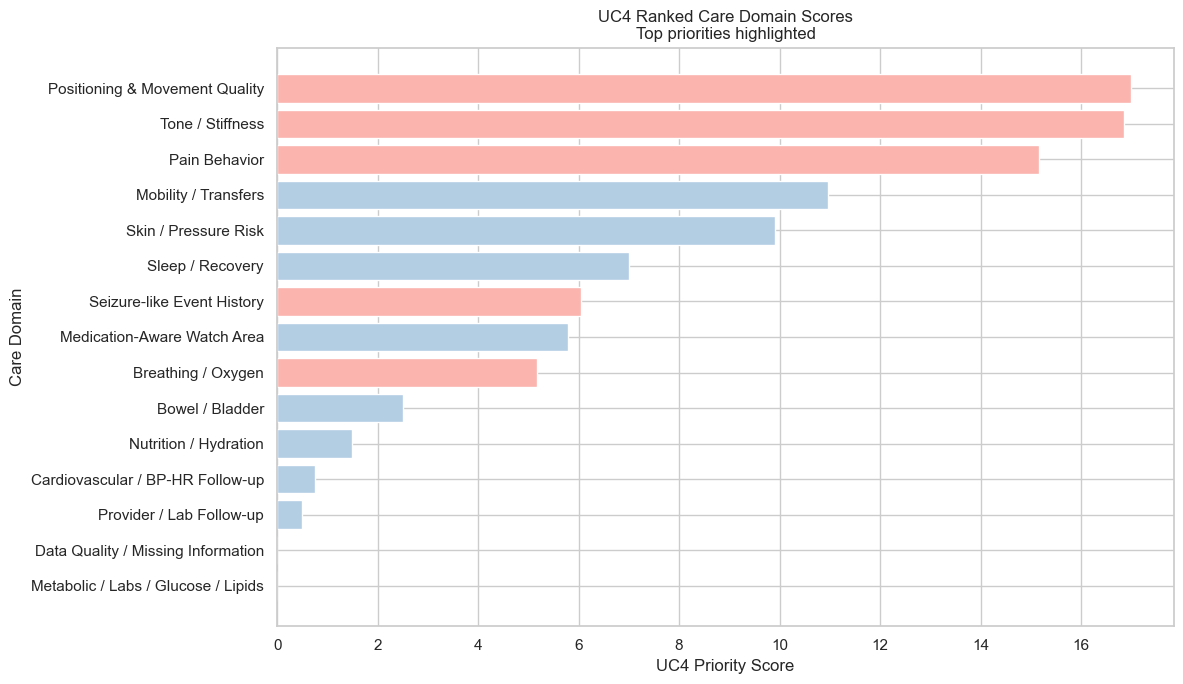

'uc4_adaptive_care_focus_outputs\\figures\\uc4_ranked_domain_scores.png'

In [25]:
plt.figure(figsize=(12, 7))
plot_df = ranked_df.sort_values("total_score", ascending=True)

colors = ["#b3cde3" if d not in top_priorities["domain"].values else "#fbb4ae" for d in plot_df["domain"]]

plt.barh(plot_df["domain_label"], plot_df["total_score"], color=colors)
plt.xlabel("UC4 Priority Score")
plt.ylabel("Care Domain")
plt.title("UC4 Ranked Care Domain Scores\nTop priorities highlighted")
plt.tight_layout()

path = os.path.join(FIG_DIR, "uc4_ranked_domain_scores.png")
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

path

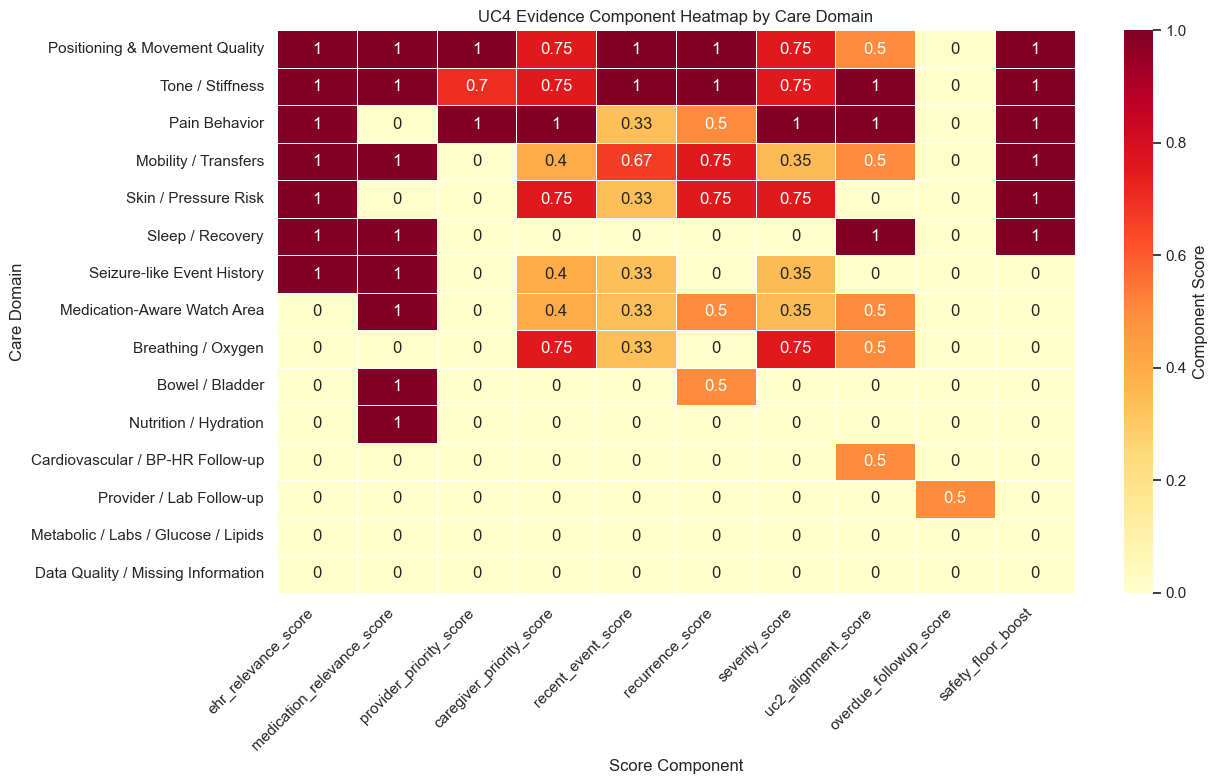

'uc4_adaptive_care_focus_outputs\\figures\\uc4_score_component_heatmap.png'

In [27]:
component_cols = [
    "ehr_relevance_score",
    "medication_relevance_score",
    "provider_priority_score",
    "caregiver_priority_score",
    "recent_event_score",
    "recurrence_score",
    "severity_score",
    "uc2_alignment_score",
    "overdue_followup_score",
    "safety_floor_boost"
]

heat_df = ranked_df.set_index("domain_label")[component_cols]

plt.figure(figsize=(13, 8))
sns.heatmap(
    heat_df,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Component Score"}
)
plt.title("UC4 Evidence Component Heatmap by Care Domain")
plt.xlabel("Score Component")
plt.ylabel("Care Domain")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

path = os.path.join(FIG_DIR, "uc4_score_component_heatmap.png")
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

path

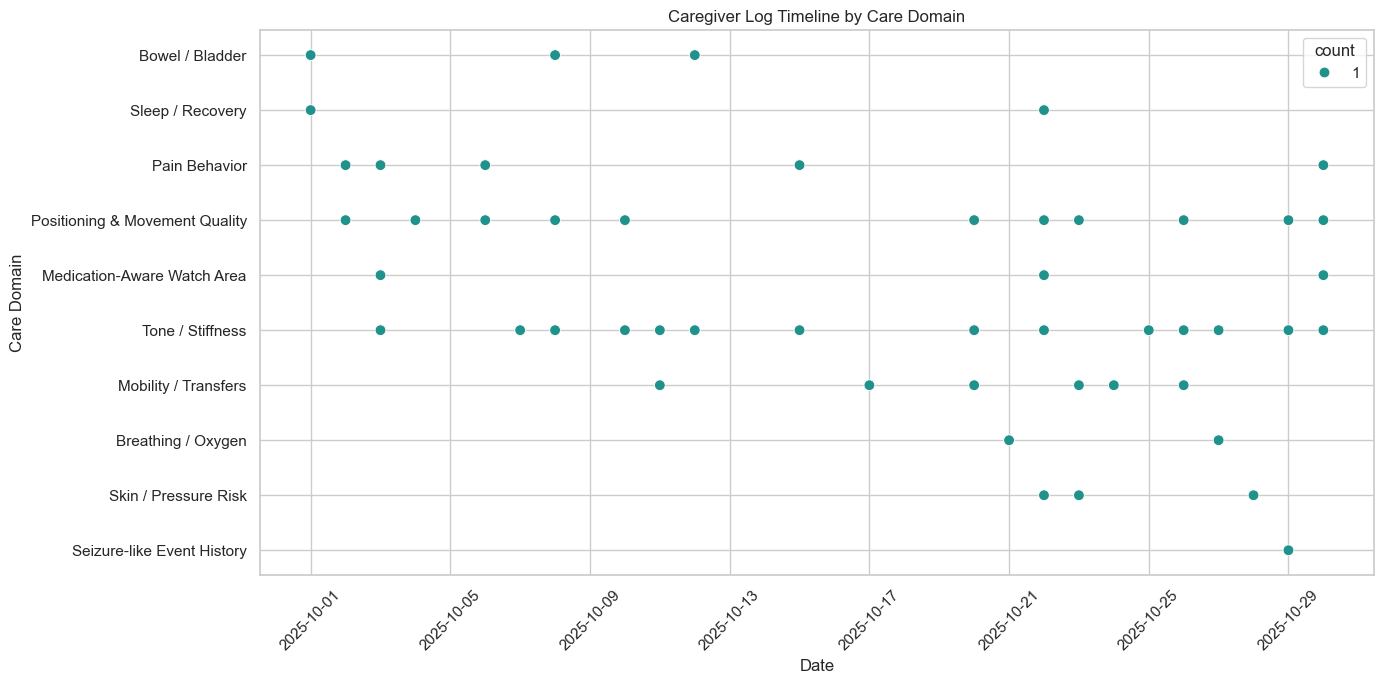

'uc4_adaptive_care_focus_outputs\\figures\\uc4_caregiver_log_timeline.png'

In [29]:
timeline_df = caregiver_logs.copy()
timeline_df["date"] = pd.to_datetime(timeline_df["timestamp"]).dt.date

counts_by_day_domain = timeline_df.groupby(["date", "domain_label"]).size().reset_index(name="count")

plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=counts_by_day_domain,
    x="date",
    y="domain_label",
    size="count",
    hue="count",
    palette="viridis",
    sizes=(60, 350),
    legend=True
)
plt.title("Caregiver Log Timeline by Care Domain")
plt.xlabel("Date")
plt.ylabel("Care Domain")
plt.xticks(rotation=45)
plt.tight_layout()

path = os.path.join(FIG_DIR, "uc4_caregiver_log_timeline.png")
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

path

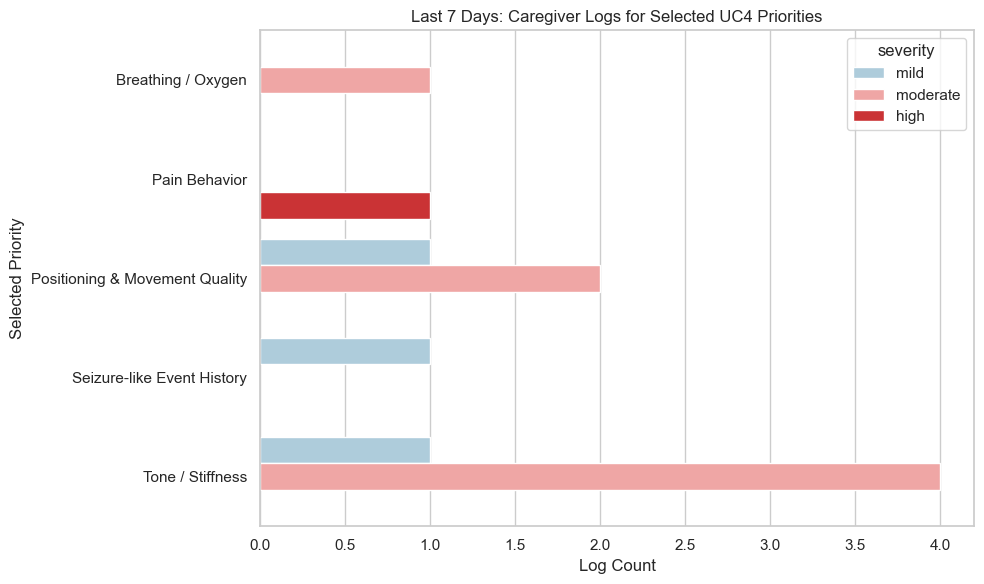

'uc4_adaptive_care_focus_outputs\\figures\\uc4_top_priority_7d_log_counts.png'

In [31]:
top_domains = top_priorities["domain"].tolist()

top_log_df = caregiver_logs[
    (caregiver_logs["domain"].isin(top_domains)) &
    (caregiver_logs["timestamp"] >= reference_date - timedelta(days=7))
].copy()

top_log_counts = top_log_df.groupby(["domain_label", "severity"]).size().reset_index(name="count")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_log_counts,
    x="count",
    y="domain_label",
    hue="severity",
    hue_order=["mild", "moderate", "high"],
    palette={"mild": "#a6cee3", "moderate": "#fb9a99", "high": "#e31a1c"}
)
plt.title("Last 7 Days: Caregiver Logs for Selected UC4 Priorities")
plt.xlabel("Log Count")
plt.ylabel("Selected Priority")
plt.tight_layout()

path = os.path.join(FIG_DIR, "uc4_top_priority_7d_log_counts.png")
plt.savefig(path, dpi=200, bbox_inches="tight")
plt.show()

path

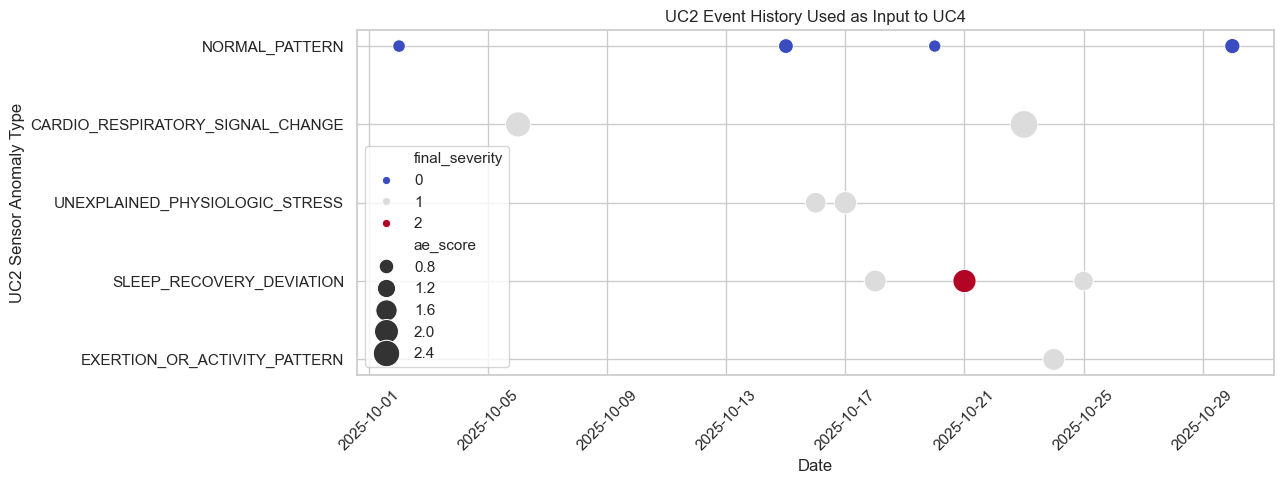

uc4_adaptive_care_focus_outputs\figures\uc4_uc2_event_history_input.png


In [33]:
if not uc2_events.empty:
    uc2_plot = uc2_events.copy()
    uc2_plot["date"] = pd.to_datetime(uc2_plot["timestamp"]).dt.date
    
    plt.figure(figsize=(13, 5))
    sns.scatterplot(
        data=uc2_plot,
        x="date",
        y="sensor_anomaly_type",
        size="ae_score",
        hue="final_severity",
        palette="coolwarm",
        sizes=(80, 400)
    )
    plt.title("UC2 Event History Used as Input to UC4")
    plt.xlabel("Date")
    plt.ylabel("UC2 Sensor Anomaly Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    path = os.path.join(FIG_DIR, "uc4_uc2_event_history_input.png")
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    
    print(path)
else:
    print("No UC2 events available.")

In [35]:
rag_documents = []

doc_id = 1

# EHR docs
for obs in patient_profile["ehr_observations"]:
    rag_documents.append({
        "doc_id": f"DOC_{doc_id:03d}",
        "source": "synthetic_ehr_observation",
        "domain_hint": obs["category"],
        "text": obs["text"]
    })
    doc_id += 1

# Provider priority docs
for item in patient_profile["provider_priorities"]:
    rag_documents.append({
        "doc_id": f"DOC_{doc_id:03d}",
        "source": "synthetic_provider_care_plan",
        "domain_hint": item["domain"],
        "text": f"Provider priority for {DOMAIN_LABELS[item['domain']]}: {item['instruction']}"
    })
    doc_id += 1

# Medication docs
for _, row in medication_profile.iterrows():
    rag_documents.append({
        "doc_id": f"DOC_{doc_id:03d}",
        "source": "synthetic_medication_profile",
        "domain_hint": row["medication_class"],
        "text": f"{row['medication_name']} is listed as {row['medication_class']}. UC4 may use this to raise medication-aware observation priorities, but must not recommend medication changes."
    })
    doc_id += 1

# Recent caregiver logs as docs
recent_logs = caregiver_logs[caregiver_logs["timestamp"] >= reference_date - timedelta(days=14)]
for _, row in recent_logs.iterrows():
    rag_documents.append({
        "doc_id": f"DOC_{doc_id:03d}",
        "source": "synthetic_caregiver_log",
        "domain_hint": row["domain"],
        "text": f"{row['timestamp'].date()} caregiver log for {row['domain_label']}: {row['text']} Severity: {row['severity']}."
    })
    doc_id += 1

# Safety templates
safety_templates = [
    {
        "domain_hint": "safety",
        "text": "Use non-diagnostic wording. The app may suggest what to watch and log, but must not diagnose, detect seizures, measure tone, or recommend medication changes."
    },
    {
        "domain_hint": "safety",
        "text": "For persistent, worsening, or concerning changes, advise caregiver to contact the care team. For severe breathing difficulty, unresponsiveness, or urgent symptoms, use emergency care."
    },
    {
        "domain_hint": "medication_safety",
        "text": "Medication-aware priorities should focus on adherence, timing, recent changes, and observations. Do not state that a medication caused a symptom."
    }
]

for item in safety_templates:
    rag_documents.append({
        "doc_id": f"DOC_{doc_id:03d}",
        "source": "approved_safety_template",
        "domain_hint": item["domain_hint"],
        "text": item["text"]
    })
    doc_id += 1

rag_df = pd.DataFrame(rag_documents)
rag_df.to_csv(os.path.join(OUTPUT_DIR, "uc4_simulated_rag_corpus.csv"), index=False)

print("RAG corpus docs:", rag_df.shape)
rag_df.head(10)

RAG corpus docs: (43, 4)


,doc_id,source,domain_hint,text
0,DOC_001,synthetic_ehr_observation,musculoskeletal,Documented spastic movement pattern and increased tone noted in lower extremities.
1,DOC_002,synthetic_ehr_observation,mobility,Requires assistance with transfers and repositioning.
2,DOC_003,synthetic_ehr_observation,neuro,History of seizure disorder; caregiver tracks seizure-like episodes.
3,DOC_004,synthetic_ehr_observation,pain,"Pain may present as guarding, grimacing, withdrawal, or sleep disruption."
4,DOC_005,synthetic_ehr_observation,skin,Positioning and limited mobility increase need for routine skin checks.
5,DOC_006,synthetic_provider_care_plan,PAIN_BEHAVIOR,Provider priority for Pain Behavior: Track pain behaviors and report persistent worsening.
6,DOC_007,synthetic_provider_care_plan,POSITIONING_MOVEMENT_QUALITY,"Provider priority for Positioning & Movement Quality: Monitor sitting posture, repositioning difficulty, and comfort."
7,DOC_008,synthetic_provider_care_plan,TONE_SPASTICITY,"Provider priority for Tone / Stiffness: Log changes in stiffness, spasms, and movement comfort."
8,DOC_009,synthetic_medication_profile,antiepileptic,"Levetiracetam is listed as antiepileptic. UC4 may use this to raise medication-aware observation priorities, but must not recommend medication changes."
9,DOC_010,synthetic_medication_profile,muscle_relaxant,"Baclofen is listed as muscle_relaxant. UC4 may use this to raise medication-aware observation priorities, but must not recommend medication changes."


In [37]:
DOMAIN_QUERY_TERMS = {
    "PAIN_BEHAVIOR": ["pain", "guarding", "grimacing", "uncomfortable", "withdrawn", "discomfort"],
    "TONE_SPASTICITY": ["tone", "stiffness", "spasm", "spastic", "tighter", "movement"],
    "POSITIONING_MOVEMENT_QUALITY": ["position", "reposition", "sitting", "slumping", "leaning", "chair", "comfort"],
    "SEIZURE_LIKE_EVENT_HISTORY": ["seizure", "episode", "repetitive", "recovered"],
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK": ["medication", "dose", "delayed", "timing", "schedule", "change"],
    "BREATHING_OXYGEN": ["breathing", "oxygen", "spo2", "respiratory", "slumped"],
    "SLEEP_RECOVERY": ["sleep", "tired", "fatigue", "recovery", "energy"],
    "BOWEL_BLADDER": ["bowel", "constipation", "bladder", "routine"],
    "MOBILITY_TRANSFERS": ["transfer", "mobility", "assistance", "stable"],
    "SKIN_PRESSURE_RISK": ["skin", "redness", "pressure", "sitting"],
    "CARDIOVASCULAR_BP_HR_FOLLOWUP": ["heart", "bp", "blood pressure", "cardio", "hr"],
    "METABOLIC_LABS_GLUCOSE_LIPIDS": ["glucose", "lipid", "lab", "metabolic"],
    "NUTRITION_HYDRATION": ["hydration", "fluid", "meal", "nutrition"],
    "PROVIDER_LAB_FOLLOWUP": ["provider", "follow", "lab", "care plan"],
    "DATA_QUALITY_OR_MISSING_INFORMATION": ["missing", "data", "quality", "stale"]
}

def simple_rag_retrieve(domain, rag_df, top_k=6):
    terms = DOMAIN_QUERY_TERMS.get(domain, [])
    safety_terms = ["diagnose", "safety", "emergency", "medication"]
    
    query_terms = set([t.lower() for t in terms + safety_terms])
    
    scored = []
    for _, row in rag_df.iterrows():
        text = row["text"].lower()
        score = 0
        
        for term in query_terms:
            if term in text:
                score += 1
        
        # Domain hint boost
        if row["domain_hint"] == domain:
            score += 3
        
        # Safety docs always modestly relevant
        if row["source"] == "approved_safety_template":
            score += 1
        
        if score > 0:
            scored.append({
                "doc_id": row["doc_id"],
                "source": row["source"],
                "domain_hint": row["domain_hint"],
                "text": row["text"],
                "retrieval_score": score
            })
    
    out = pd.DataFrame(scored)
    if out.empty:
        return out
    
    return out.sort_values(["retrieval_score", "doc_id"], ascending=[False, True]).head(top_k).reset_index(drop=True)

# Test simulated RAG
test_domain = top_priorities.iloc[0]["domain"]
simple_rag_retrieve(test_domain, rag_df, top_k=6)

,doc_id,source,domain_hint,text,retrieval_score
0,DOC_007,synthetic_provider_care_plan,POSITIONING_MOVEMENT_QUALITY,"Provider priority for Positioning & Movement Quality: Monitor sitting posture, repositioning difficulty, and comfort.",7
1,DOC_016,synthetic_caregiver_log,POSITIONING_MOVEMENT_QUALITY,2025-10-20 caregiver log for Positioning & Movement Quality: Leaning more to one side while sitting. Severity: moderate.,6
2,DOC_018,synthetic_caregiver_log,POSITIONING_MOVEMENT_QUALITY,2025-10-22 caregiver log for Positioning & Movement Quality: Leaning more to one side while sitting. Severity: mild.,6
3,DOC_036,synthetic_caregiver_log,POSITIONING_MOVEMENT_QUALITY,2025-10-29 caregiver log for Positioning & Movement Quality: Leaning more to one side while sitting. Severity: moderate.,6
4,DOC_024,synthetic_caregiver_log,POSITIONING_MOVEMENT_QUALITY,2025-10-23 caregiver log for Positioning & Movement Quality: Harder to reposition today. Severity: mild.,5
5,DOC_029,synthetic_caregiver_log,POSITIONING_MOVEMENT_QUALITY,2025-10-26 caregiver log for Positioning & Movement Quality: Harder to reposition today. Severity: mild.,5


In [39]:
CHECKLIST_TEMPLATES = {
    "PAIN_BEHAVIOR": [
        "Any grimacing, guarding, withdrawal, irritability, or behavior that looks different from baseline?",
        "Does discomfort seem linked with repositioning, transfers, sleep, bowel routine, or movement?",
        "If pain behavior is persistent, worsening, or concerning, document the pattern and contact the care team."
    ],
    "TONE_SPASTICITY": [
        "Is stiffness different from Mike's usual baseline today?",
        "Any increase in spasms, repetitive movements, or difficulty relaxing during care?",
        "Does stiffness seem connected to poor sleep, discomfort, positioning, or medication timing?"
    ],
    "POSITIONING_MOVEMENT_QUALITY": [
        "Is Mike leaning, slumping, or sitting differently than usual?",
        "Was repositioning or transfer support harder than usual?",
        "Does he seem uncomfortable or guarded in a specific position?",
        "Any skin redness, pressure area, or breathing discomfort related to position?"
    ],
    "SEIZURE_LIKE_EVENT_HISTORY": [
        "Any seizure-like episode or unusual repetitive movement to log?",
        "How long did it last, what happened before it, and how did recovery compare with baseline?",
        "This app supports logging only; it does not detect or diagnose seizures."
    ],
    "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK": [
        "Any missed, delayed, or uncertain doses?",
        "Any recent medication schedule changes?",
        "Log observations around medication timing without changing medication unless directed by the care team."
    ],
    "BREATHING_OXYGEN": [
        "Any breathing that seems harder than usual?",
        "Any concern related to position, sleep, fatigue, or oxygen readings if available?",
        "Use urgent/emergency care for severe breathing difficulty or unresponsiveness."
    ],
    "SLEEP_RECOVERY": [
        "Was sleep worse than usual last night?",
        "Any increased fatigue, lower engagement, or reduced activity today?",
        "Does poor sleep seem linked with pain, stiffness, breathing, or medication timing?"
    ],
    "BOWEL_BLADDER": [
        "Any missed bowel routine, constipation concern, or bladder routine issue?",
        "Any discomfort, guarding, appetite change, or sleep disruption that may coincide with bowel/bladder routine?",
        "Log persistent or worsening changes for the care team."
    ],
    "MOBILITY_TRANSFERS": [
        "Were transfers harder or less stable than usual?",
        "Was more assistance needed than Mike's baseline?",
        "Any pain behavior, stiffness, or positioning issue during transfers?"
    ],
    "SKIN_PRESSURE_RISK": [
        "Any redness, pressure mark, or skin area that looks different from baseline?",
        "Did one position or longer sitting period seem related?",
        "Escalate to the care team for persistent, worsening, open, or concerning skin changes."
    ],
    "CARDIOVASCULAR_BP_HR_FOLLOWUP": [
        "Any unusual heart rate, blood pressure reading if available, dizziness, or fatigue?",
        "Any repeated UC2 cardio-respiratory alerts this week?",
        "Contact the care team for persistent or concerning changes."
    ],
    "PROVIDER_LAB_FOLLOWUP": [
        "Any overdue appointments, labs, or care-plan review tasks?",
        "Any repeated logs that should be summarized for the provider?",
        "Prepare a concise summary for the next care-team contact."
    ]
}

def generate_why_text(row, retrieved_docs):
    reasons = []
    
    if row["provider_priority"]:
        reasons.append("this area is listed in the care plan/provider priorities")
    if row["ehr_match_count"] > 0:
        reasons.append("Mike's profile contains relevant history for this area")
    if row["medication_match_count"] > 0:
        reasons.append("his medication profile makes this a useful observation area")
    if row["caregiver_logs_7d"] > 0:
        reasons.append(f"there were {row['caregiver_logs_7d']} related caregiver log(s) in the last 7 days")
    if row["uc2_related_events_14d"] > 0:
        reasons.append(f"there were {row['uc2_related_events_14d']} related UC2 event(s) in the last 14 days")
    
    if not reasons:
        reasons.append("this area has some background relevance")
    
    why = "This is on the list because " + ", ".join(reasons) + "."
    why += " This is not a diagnosis; it is a caregiver focus area for observation and documentation."
    return why

def generate_escalation_text(domain):
    if domain == "SEIZURE_LIKE_EVENT_HISTORY":
        return "Log event details and recovery. Contact the care team for recurrent, prolonged, unusual, or concerning events. Use emergency care if there is unresponsiveness, breathing difficulty, injury, or urgent concern."
    if domain == "BREATHING_OXYGEN":
        return "For severe breathing difficulty, blue/gray color, unresponsiveness, or urgent concern, use emergency care. For persistent or worsening mild concerns, contact the care team."
    if domain == "SKIN_PRESSURE_RISK":
        return "Contact the care team for persistent redness, open skin, worsening pressure areas, or signs of infection."
    if domain == "MEDICATION_ADHERENCE_OR_MEDICATION_AWARE_RISK":
        return "Do not change medications in the app. Log missed/delayed doses and contact the care team/pharmacy if medication timing or effects are concerning."
    return "If this pattern is persistent, worsening, associated with severe symptoms, or feels concerning, contact the care team or use urgent/emergency care as appropriate."

def build_priority_output(row):
    domain = row["domain"]
    retrieved = simple_rag_retrieve(domain, rag_df, top_k=6)
    
    checklist = CHECKLIST_TEMPLATES.get(domain, [
        "Check whether this area is different from baseline.",
        "Log what changed, when it happened, and whether it is improving or worsening.",
        "Contact the care team for persistent or concerning changes."
    ])
    
    output = {
        "priority_rank": int(row["priority_rank"]),
        "domain": domain,
        "title": DOMAIN_LABELS[domain],
        "priority_level": row["priority_level"],
        "priority_score": float(row["total_score"]),
        "why_this_is_on_the_list": generate_why_text(row, retrieved),
        "checklist_items": checklist,
        "escalation_guidance": generate_escalation_text(domain),
        "retrieved_evidence": retrieved.to_dict(orient="records"),
        "safety_flags": {
            "diagnosis_generated": False,
            "medication_change_recommended": False,
            "seizure_detection_claimed": False,
            "tone_measurement_claimed": False,
            "emergency_suppressed": False
        }
    }
    return output

priority_outputs = [build_priority_output(row) for _, row in top_priorities.iterrows()]

with open(os.path.join(OUTPUT_DIR, "uc4_weekly_priority_outputs_with_simulated_rag.json"), "w") as f:
    json.dump(priority_outputs, f, indent=2, default=str)

priority_outputs[0]

{'priority_rank': 1,
 'domain': 'POSITIONING_MOVEMENT_QUALITY',
 'title': 'Positioning & Movement Quality',
 'priority_level': 'PROVIDER_REVIEW_RECOMMENDED',
 'priority_score': 17.0,
 'why_this_is_on_the_list': "This is on the list because this area is listed in the care plan/provider priorities, Mike's profile contains relevant history for this area, his medication profile makes this a useful observation area, there were 3 related caregiver log(s) in the last 7 days, there were 1 related UC2 event(s) in the last 14 days. This is not a diagnosis; it is a caregiver focus area for observation and documentation.",
 'checklist_items': ['Is Mike leaning, slumping, or sitting differently than usual?',
  'Was repositioning or transfer support harder than usual?',
  'Does he seem uncomfortable or guarded in a specific position?',
  'Any skin redness, pressure area, or breathing discomfort related to position?'],
 'escalation_guidance': 'If this pattern is persistent, worsening, associated with

In [41]:
def print_weekly_checklist(priority_outputs, patient_name="Mike"):
    print("=" * 90)
    print(f"UC4 Adaptive Care Focus Checklist — {patient_name}")
    print("Synthetic demo output. Not diagnostic. For caregiver support and documentation.")
    print("=" * 90)
    print()
    
    for item in priority_outputs:
        print(f"{item['priority_rank']}. {item['title']}")
        print(f"   Priority level: {item['priority_level']}")
        print(f"   Score: {item['priority_score']:.2f}")
        print()
        print("   Why this is on the list:")
        print(textwrap.fill("   " + item["why_this_is_on_the_list"], width=100))
        print()
        print("   Checklist:")
        for q in item["checklist_items"]:
            print(f"   [ ] {q}")
        print()
        print("   When to escalate:")
        print(textwrap.fill("   " + item["escalation_guidance"], width=100))
        print()
        print("-" * 90)

print_weekly_checklist(priority_outputs, patient_name="Mike Demo")

UC4 Adaptive Care Focus Checklist — Mike Demo
Synthetic demo output. Not diagnostic. For caregiver support and documentation.

1. Positioning & Movement Quality
   Priority level: PROVIDER_REVIEW_RECOMMENDED
   Score: 17.00

   Why this is on the list:
   This is on the list because this area is listed in the care plan/provider priorities, Mike's
profile contains relevant history for this area, his medication profile makes this a useful
observation area, there were 3 related caregiver log(s) in the last 7 days, there were 1 related UC2
event(s) in the last 14 days. This is not a diagnosis; it is a caregiver focus area for observation
and documentation.

   Checklist:
   [ ] Is Mike leaning, slumping, or sitting differently than usual?
   [ ] Was repositioning or transfer support harder than usual?
   [ ] Does he seem uncomfortable or guarded in a specific position?
   [ ] Any skin redness, pressure area, or breathing discomfort related to position?

   When to escalate:
   If this patt